# Submit batch job to subset and save SPEAR-HI25 heat fluxes

Var names to download:
- lwflx
- shflx
- swup_sfc
- swdn_sfc
- evap

1. Run `01_copy_over_spear_folders` which pulls from `02_submit_copy_cmd`
2. Then run code below which works with `03_submit_batch_ncks_ncrcat_spear`

In [3]:
import os
base_dir = '/work5/stb/MHW-gfdl/SPEAR'
#nco_fnc_str = 'ncks -O -d xT,-98.0,-10.0 -d yT,0.0,31.0'
#nco_fnc_str = 'ncks -O -d lon,262.0,350.0 -d lat,0.0,31.0'
batch_script = f'{base_dir}/03_submit_batch_ncks_ncrcat_spear'
#batch_script = f'{base_dir}/03_check_for_fils'

var_dict = {'ocean':{'var_list':['SST'], 
                     'ncks_str':'ncks -O -d xT,-98.0,-10.0 -d yT,0.0,31.0'},
           'atmos':{'var_list':['lwflx', 'shflx', 'swup_sfc', 'swdn_sfc', 'evap', 't_surf'],
                     'ncks_str':'ncks -O -d lon,262.0,350.0 -d lat,0.0,31.0'}}
yr0 = 1991
yrn = 2100
outdir = base_dir

nfil = 0
for ens_m in range(30):
    ens_str = str(ens_m+1).zfill(2) # ensemble string - zero padded
    indir = f'{base_dir}/SPEAR_c384_OM4p25_Hist_SSP245_IC1991_R61_ens_{ens_str}'

    #for var_type in var_dict:
    for var_type in ['atmos']:
        # creating a single string with all the variables for bash to work with
        bash_list = ''
        for var_nm in var_dict[var_type]['var_list']:
            bash_list = f'{bash_list} {var_nm}'

        # bringing together the sbatch command
        sbatch_fnc_str = f'sbatch --partition=batch {batch_script} {indir} {ens_str} {yr0} {yrn} "{bash_list}"'
        sbatch_fnc_str = f"{sbatch_fnc_str} '{var_dict[var_type]['ncks_str']}' {indir}"
 
        nfil+=1
        #print(ncfile)
        #outfile = f'{indir}/{var_nm}_ens{ens_str}_{ens_yr}.nc'
        os.system(sbatch_fnc_str)

print(nfil)

Submitted batch job 53814002
Submitted batch job 53814003
Submitted batch job 53814004
Submitted batch job 53814005
Submitted batch job 53814006
Submitted batch job 53814007
Submitted batch job 53814008
Submitted batch job 53814009
Submitted batch job 53814010
Submitted batch job 53814011
Submitted batch job 53814012
Submitted batch job 53814013
Submitted batch job 53814014
Submitted batch job 53814015
Submitted batch job 53814016
Submitted batch job 53814017
Submitted batch job 53814018
Submitted batch job 53814019
Submitted batch job 53814020
Submitted batch job 53814021
Submitted batch job 53814022
Submitted batch job 53814023
Submitted batch job 53814024
Submitted batch job 53814025
Submitted batch job 53814026
Submitted batch job 53814027
Submitted batch job 53814028
Submitted batch job 53814029
Submitted batch job 53814030
Submitted batch job 53814031
30


In [4]:
import xarray as xr

path ='/work5/stb/MHW-gfdl/SPEAR/SPEAR_c384_OM4p25_Hist_SSP245_IC1991_R61_ens_01/evap_ens01_1991-2100.nc'
ds = xr.open_dataset(path, decode_timedelta=True, chunks={})

In [6]:
ds.evap

<xarray.DataArray 'evap' (time: 38350, lat: 124, lon: 282)> Size: 5GB
dask.array<open_dataset-evap, shape=(38350, 124, 282), dtype=float32, chunksize=(38350, 124, 282), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 307kB 1991-01-01 12:00:00 ... 2100-12-31 12:00:00
  * lat      (lat) float64 992B 0.125 0.375 0.625 0.875 ... 30.38 30.63 30.88
  * lon      (lon) float64 2kB 262.0 262.3 262.7 263.0 ... 349.2 349.5 349.8
Attributes:
    units:          kg/m2/s
    long_name:      evaporation rate
    cell_methods:   time: mean
    time_avg_info:  average_T1,average_T2,average_DT
    interp_method:  conserve_order2

In [7]:
#check if time dim is increasing monotonically
ds.time.diff("time").min()

<xarray.DataArray 'time' ()> Size: 8B
array(86400000000, dtype='timedelta64[us]')
Attributes:
    long_name:      time
    axis:           T
    calendar_type:  JULIAN
    bounds:         time_bnds

In [10]:
ds.evap[0]

<xarray.DataArray 'evap' (lat: 124, lon: 282)> Size: 140kB
dask.array<getitem, shape=(124, 282), dtype=float32, chunksize=(124, 282), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 992B 0.125 0.375 0.625 0.875 ... 30.38 30.63 30.88
  * lon      (lon) float64 2kB 262.0 262.3 262.7 263.0 ... 349.2 349.5 349.8
    time     object 8B 1991-01-01 12:00:00
Attributes:
    units:          kg/m2/s
    long_name:      evaporation rate
    cell_methods:   time: mean
    time_avg_info:  average_T1,average_T2,average_DT
    interp_method:  conserve_order2

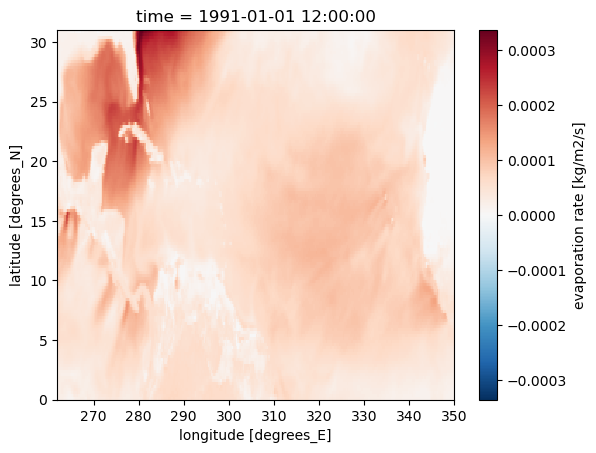

In [9]:
ds.evap[0].plot()